# Working with magnetic field models in PySPEDAS

This notebook demonstrates some of PySPEDAS's capabilities for modeling Earth's magnetic field under varying solar wind and magnetospheric conditions, comparing different field models to each other and to spacecraft observations, and tracing magnetic field lines to their foot points near Earth, or to their apex or magnetic equator points.

First, we'll ensure that a recent version of PySPEDAS is installed, and import some of the tools we need to get started.

In [20]:
# Install PySPEDAS version that supports the capabiliies of this notebook
# You may skip or comment this cell if you know your PySPEDAS installation is up to date
#%pip install "pyspedas[all]>=2.1.3"

In [21]:
# Import some PySPEDAS routines for loading and plotting THEMIS positions and magnetic fields

import pyspedas
from pyspedas.projects.themis import state, fgm


## Loading THEMIS orbit and magnetometer data

Magnetic field models vary with time and position.  For these inputs. we'll use some THEMIS ephemeris data.  We'll also load some THEMIS magnetic field data to compare to the model outputs.

The time interval we'll look at, May 24, 2023, had some interesting geomagnetic activity.

In [22]:
# Set the time range of interest
trange=['2023-03-24','2023-03-25']
# Load THEMIS ephemeris
state_vars = state(probe='a',trange=trange)
# Load THEMIS fluxgate magnetometer data
fgm_vars = fgm(probe='a',trange=trange)



11-Jul-26 01:33:36: File is current: themis_data/tha/l1/state/2023/tha_l1_state_20230324.cdf
11-Jul-26 01:33:36: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fgm/2023/
11-Jul-26 01:33:37: File is current: themis_data/tha/l2/fgm/2023/tha_l2_fgm_20230324_v01.cdf


## Time series plots of THEMIS ephemeris and magnetic field observations

Let's plot the positions and magnetic field observations we just loaded.  The THEMIS data files contain positions and magnetic fields available in several coordinate systems; for this demo, the data in GSM coordinates would be the best choice.  The geopack library PySPEDAS uses to work with the magnetic field models uses GSM coordinates internally.  Note: if the input positions have correct metadata, and are in one of several well-known coordinate systems (e.g. GEI, GSE, GEO), PySPEDAS will perform the appropriate coordinate transformations before passing the position data to geopack.  But in this case, since we already have the positions in GSM, there's no need to transform them.


For the magnetic field observations, we'll use the THEMIS 'fgs' data types, which are onboard spin fits at a cadence of one sample per spin (approximately 3-4 seconds).

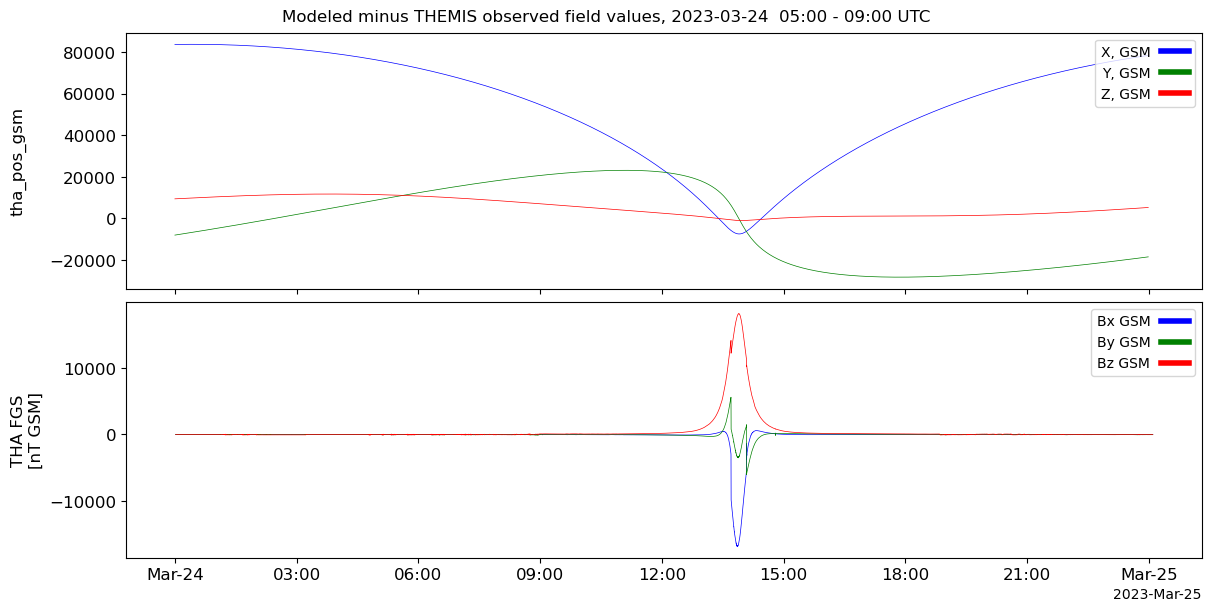

In [23]:
# Import the tplot routine for plotting time series tplot variables

from pyspedas import tplot

# Plot the THEMIS-A positions versus time

tplot('tha_pos_gsm tha_fgs_gsm')

## Magnetic field models available via the PySPEDAS interface to geopack

The geopack library includes implementations of several field models:

IGRF (standard IGRF model)
t89 (Tsyganengo 1989)
t96 (Tsyagnenko 1996)
t01 (Tsyganengo 2001)
ts04 (Tsytanenko-Sitnov 2004)

Each of these models takes a different set of input variables representing the solar wind and magnetospheric conditions to be used to produce the model outputs.

IGRF: base model, no other dependencies
t89: Kp index
t96: Pdyn (solar wind dynamic pressure), Dst (storm index), BY_imf, BZ_imf (Y and Z components of interplanetary magnetic field, in GSM coordinates)
t01: Pdyn, Dst, BY_imf. BZ_imf. g1, g2 (G1 and G2 indices are calculated from some other parameters)
ts04: Pdyn, Dst, BY_imf, BZ_imf, w1...w6 (W1...W6 indices are calculated from some other parameters)

We won't go into the t01 or ts04 models here, since the W and G parameters they use are not easy to load or calculate.   

For t89 and t96, there are some well known sources for the model parametsrs:

Kp, Dst indices: Kyoto World Data Center
Pdyn, BY_imf, BZ_imf: OMNIweb (provided by NASA's Space Physics Data Facility)

PySPEDAS includes load routines to load these parameters from Kyoto or SPDF. The resulting tplot variables can be passed as arguments to each of the models, and PySPEDAS will do some sanitization and interpolation steps to ensure that the model parameters are given at the same cadence as the input positions. It is also possible to pass the model parameters as constants, to be applied for the entire time interval of interest.  If the parameters are left completely unspecified, they will default to somewhat reasonable values.

However, most PySPEDAS users won't have to worry about how to download the model inputs. The PySPEDAS interface to the geopack libary has the ability to automatically download each model's parameters from the apprpriate sources, so that's what we'll demonstrate here.

We'll start with the T89 model:

In [24]:
from pyspedas.geopack import tt89

tt89('tha_pos_gsm',autoload=True)

11-Jul-26 01:33:44: Setting units for input_var_re
11-Jul-26 01:33:44: Loading geomagnetic index data from https://datapub.gfz-potsdam.de/download/10.5880.Kp.0001/Kp_definitive/
11-Jul-26 01:33:45: File is current: geom_indices/Kp_def2023.wdc
11-Jul-26 01:33:45: tdeflag was applied to: Kp_deflag
11-Jul-26 01:33:45: tinterpol (nearest) was applied to: Kp_itrp
11-Jul-26 01:33:45: Setting coordinate system for tha_pos_gsm_bt89
11-Jul-26 01:33:45: Setting units for tha_pos_gsm_bt89


'tha_pos_gsm_bt89'

The output of the tt89 call will be a tplot variable containing the modeled magnetic field vectors, in units of nT, in the GSM coordinate system by default.   The output variable name will be the input variable with a suffix indicating which field model was used (in this case, '_bt89')

For this example, we'll also look at the T96 model. In this case, we'll show how to download the model parameters from Kyoto and OMNIweb and pass them explicitly to the modeling routine tt96().

In [25]:
from pyspedas.geopack import tt96
from pyspedas.projects.kyoto import dst as load_dst
from pyspedas.projects.omni.load import load as load_omni
from pyspedas import time_double

# Pad the support data to ensure the entire time range is well covered
# We'll have to convert from strings to Unix times first
trange_unix = time_double(trange)
support_trange = [trange_unix[0] - 3600.0, trange_unix[1] + 3600.0]

# Load the Kyoto Dst index
load_dst(trange=support_trange)
# Load the OMNI data
load_omni(trange=support_trange)
# Set the tplot variable names corresponding to the model parameters
pdyn = 'Pressure'
byimf = 'BY_GSM'
bzimf = 'BZ_GSM'
dst='kyoto_dst'

tt96('tha_pos_gsm', pdyn=pdyn, byimf=byimf, bzimf=bzimf, dst=dst)


11-Jul-26 01:33:53: Remote file not found: http://wdc.kugi.kyoto-u.ac.jp/dst_final/202303/index.html
11-Jul-26 01:33:53: No local files found for http://wdc.kugi.kyoto-u.ac.jp/dst_final/202303/index.html
11-Jul-26 01:33:53: Error occurred while downloading: http://wdc.kugi.kyoto-u.ac.jp/dst_final/202303/index.html
11-Jul-26 01:33:54: File is current: pydata/geom_indices/kyoto/dst_provisional/202303/index.html
11-Jul-26 01:33:54: 
            ******************************
            The DST data are provided by the World Data Center for Geomagnetism, Kyoto, and
            are not for redistribution (http://wdc.kugi.kyoto-u.ac.jp/). Furthermore, we thank
            the geomagnetic observatories (Kakioka [JMA], Honolulu and San Juan [USGS], Hermanus
            [RSA], Alibag [IIG]), NiCT, INTERMAGNET, and many others for their cooperation to
            make the Dst index available.
            ******************************
        
11-Jul-26 01:33:54: Downloading remote index: https

'tha_pos_gsm_bt96'

(Don't be alarmed at warnings about "Remote files not found"!  PySPEDAS attempts to use definitive data first, and if it's not available for that time range, as happens here, it falls back to using provisionsal data.)

Now we have a variable 'tha_pos_gsm_bt96' containing the T96 model outputs.

Now let's plot the model parameters (Kp for T89; Dst, Pdyn, IMF BY and BZ for T96) and the model outputs.

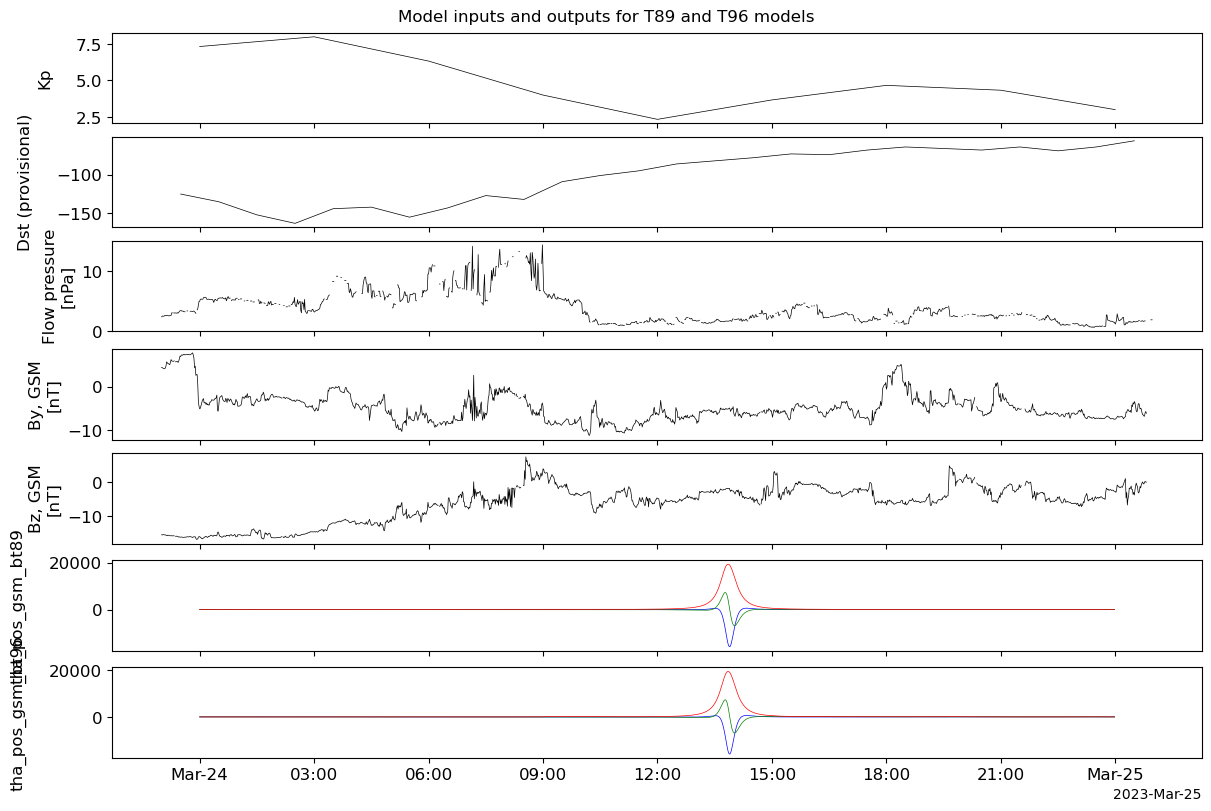

In [26]:
from pyspedas import tplot_options

tplot_options('title', 'Model inputs and outputs for T89 and T96 models')
tplot('Kp kyoto_dst Pressure BY_GSM BZ_GSM tha_pos_gsm_bt89 tha_pos_gsm_bt96')

Any small variations in the field models or measurements are being swamped by the high field values near perigee.  Let's try subtracting off the THEMIS observations from the two field model variables.  The THEMIS observations are at a different time cadence than the orbit positions and the model values derived from the rbit positions, so we'll interpolate the 1-minute modeled fields onto the ~3 sec THEMIS measurements, then do the subtraction.

In [27]:
from pyspedas import tinterpol
from pyspedas import get_data, store_data, options

# Interpolate the models to the FGM measurements

tinterpol('tha_pos_gsm_bt89', 'tha_fgs_gsm')
tinterpol('tha_pos_gsm_bt96', 'tha_fgs_gsm')

# Get the interpolated data values as numpy arrays

d89 = get_data('tha_pos_gsm_bt89-itrp')
d89_meta = get_data('tha_pos_gsm_bt89-itrp', metadata=True)
d96 = get_data('tha_pos_gsm_bt96-itrp')
d96_meta = get_data('tha_pos_gsm_bt96-itrp', metadata=True)

fgs = get_data('tha_fgs_gsm')
fgs_meta = get_data('tha_fgs_gsm', metadata=True)

# Now we know that all the times line up, so we can subtract off the THEMIS observations

sub89 = d89.y - fgs.y
sub96 = d96.y - fgs.y
times = fgs.times

# Make new tplot variables from the subtracted values. Keep the metadata from the original variables

store_data('t89_thm_diff',data={'x':times, 'y': sub89}, attr_dict=fgs_meta)
store_data('t96_thm_diff',data={'x':times, 'y': sub96}, attr_dict=fgs_meta)

# Update the labels
options('t89_thm_diff','ytitle','T89 - FGS')
options('t96_thm_diff','ytitle','T96 - FGS')


11-Jul-26 01:34:12: tinterpol (linear) was applied to: tha_pos_gsm_bt89-itrp
11-Jul-26 01:34:12: tinterpol (linear) was applied to: tha_pos_gsm_bt96-itrp


Now plot the subtracted values

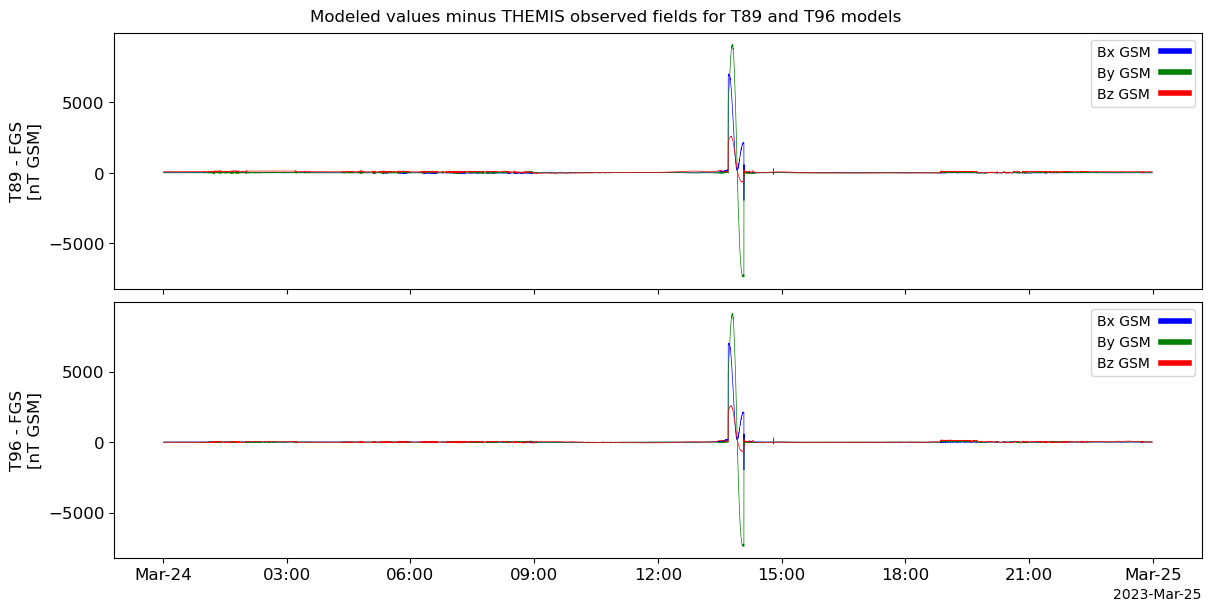

In [28]:
tplot_options('title', 'Modeled values minus THEMIS observed fields for T89 and T96 models')
tplot('t89_thm_diff t96_thm_diff')

There are still some large differences around perigee that make finer comparisons difficult....let's zoom into the first part of the day using the trange parameter to tplot.  We'll also include the solar wind parameters.

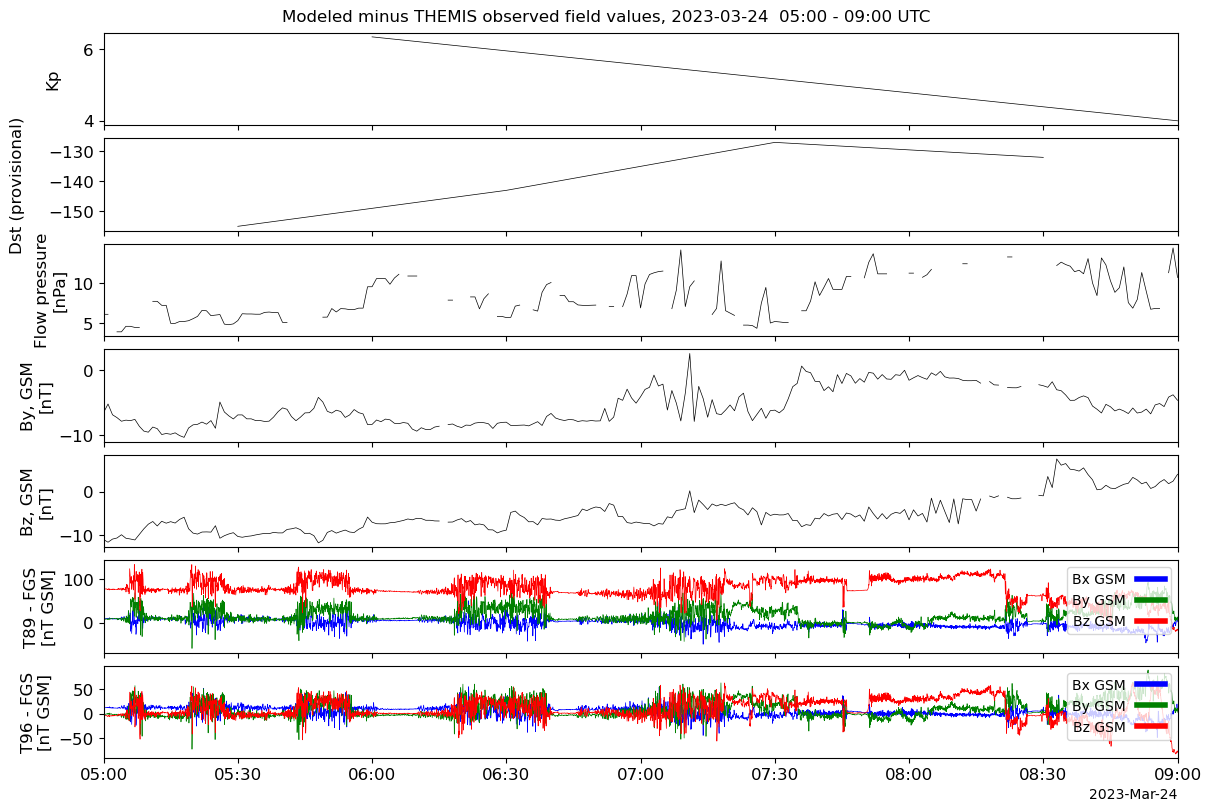

In [29]:
tplot_options('title','Modeled minus THEMIS observed field values, 2023-03-24  05:00 - 09:00 UTC')
tplot('Kp kyoto_dst Pressure BY_GSM BZ_GSM t89_thm_diff t96_thm_diff', trange=['2023-03-24 05:00', '2023-03-24 09:00'])

It appears that, at least for these solar wind conditions and region of interest, the T96 model is a better fit to the THEMIS data than the T89 model, especially the Bz component.

The noisier time intervals look like they might be magnetopause crossings.  But why are there several of them?

## Orbit plots with tplotxy3

It can be difficult to visualize the shape and orientation of a spacecraft orbit from a time series plot of the vector components.
It would be nice to see the entire orbit of THEMIS-A during this time range in 3D space, and espcially to see how it compares to the magnetopause boundary location.

We can use the tplotxy3 routine to make 3-dimensional plots of spatial data like orbits, regions of interest, or field lines.

For this example, we will show the THEMIS-A orbit relative to Earth, projected onto three different planes: XY (top, viewed from over Earth's north pole), XZ (bottom left, viewed from above the equator at the dusk side), and YZ (bottom right, viewed from the Sun) in GSM coordinates, in units of Re.

We'll set a few options to ensure that the plots are centered on Earth, and that the sun is shown to the left, as it is in the THEMIS online summary plots.

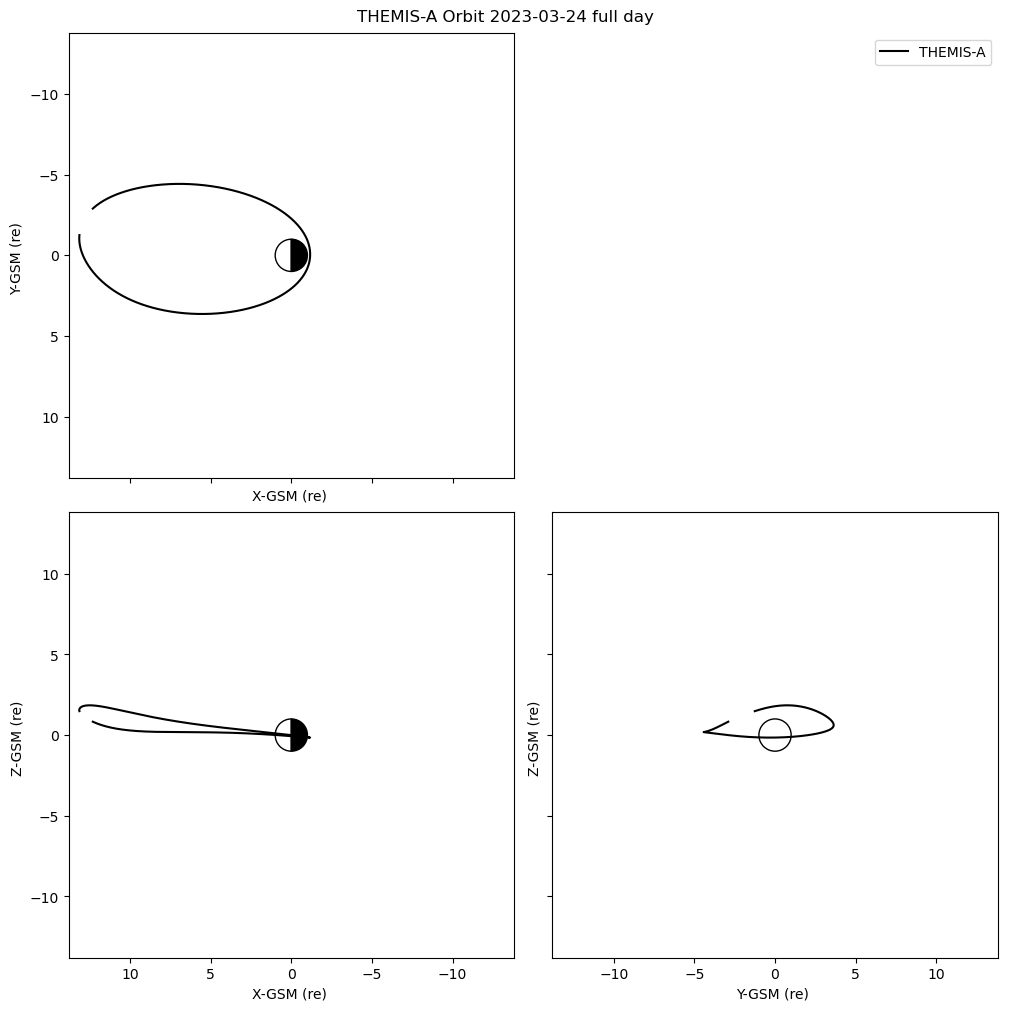

In [30]:
from pyspedas import tplotxy3

fig = tplotxy3('tha_pos_gsm',center_origin=True, reverse_x=True, title="THEMIS-A Orbit 2023-03-24 full day", legend_names=["THEMIS-A"])

Let's narrow the time interval to the time range we zoomed in on above.  We'll use time_clip for that.

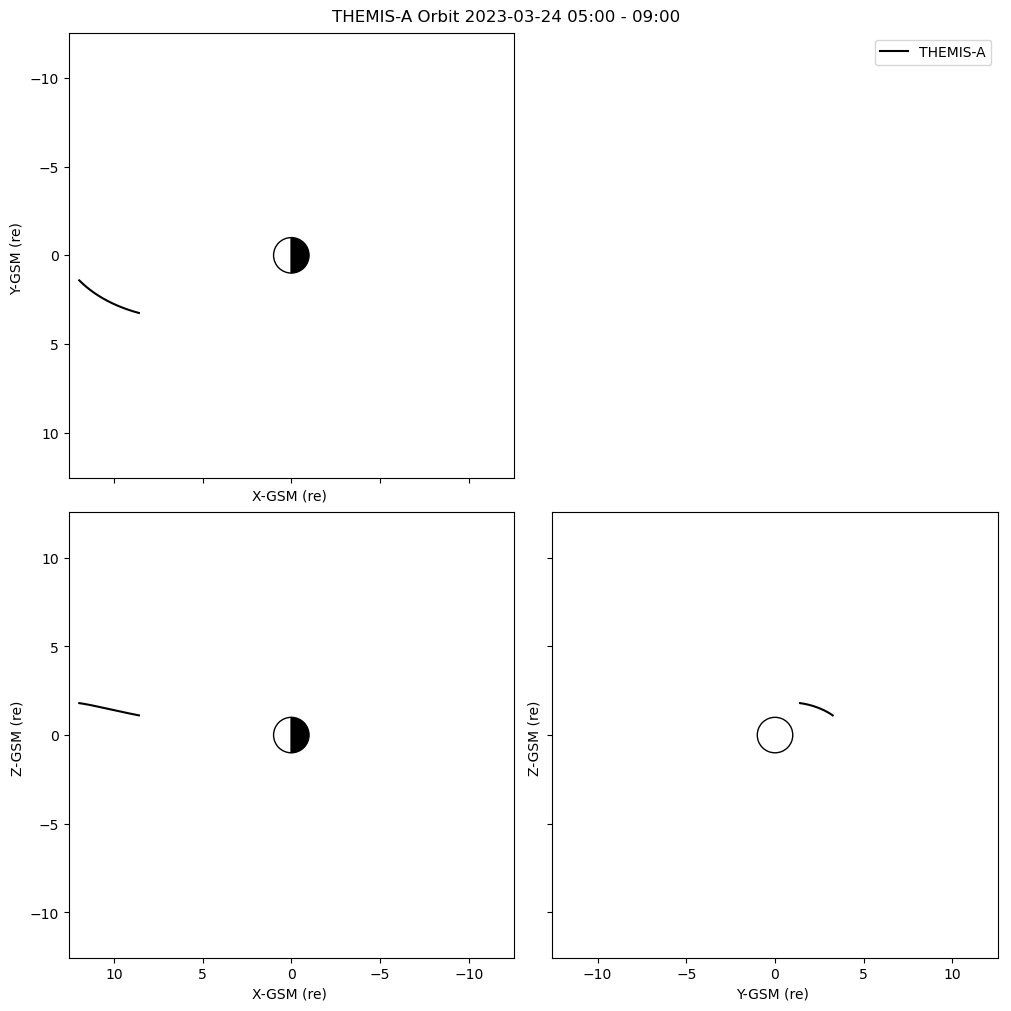

In [31]:
from pyspedas import time_clip

time_clip('tha_pos_gsm',time_start="2023-03-24/05:00", time_end="2023-03-24/09:00",newname='tha_pos_tclip')
fig = tplotxy3('tha_pos_tclip',center_origin=True, reverse_x=True, title="THEMIS-A Orbit 2023-03-24 05:00 - 09:00",legend_names=["THEMIS-A"])

Where was the magnetopause boundary around this time?  PySPEDAS has several magnetopause models available.  We'll use the T96 model, which takes the dynamic pressure as an argument.  Looking at the solar wind data above, we can see that Pdyn ranges from about 4 to 14 nPa during this time interval, so we'll compute and plot boundaries for both values.

The return values we're interested in for the magnetopause models are the first two outputs, the X and Y positions of the boundary in GSM coordinates, in units of Earth radii.

The X and Y values are presumed to be rotationaly symmetric around the X axis.   We have a special routine tplotxy3_add_mpause() to add the boundary to a tplotxy3 map under this assumption:  the boundary will be shown in the XY and XZ planes.  Since the YZ plane is a head-on view from the sun, we can't plot a single boundary unless we make assumptions about what X value should be used.  So tplotxy3_add_mpause() simply ignores the YZ plane.

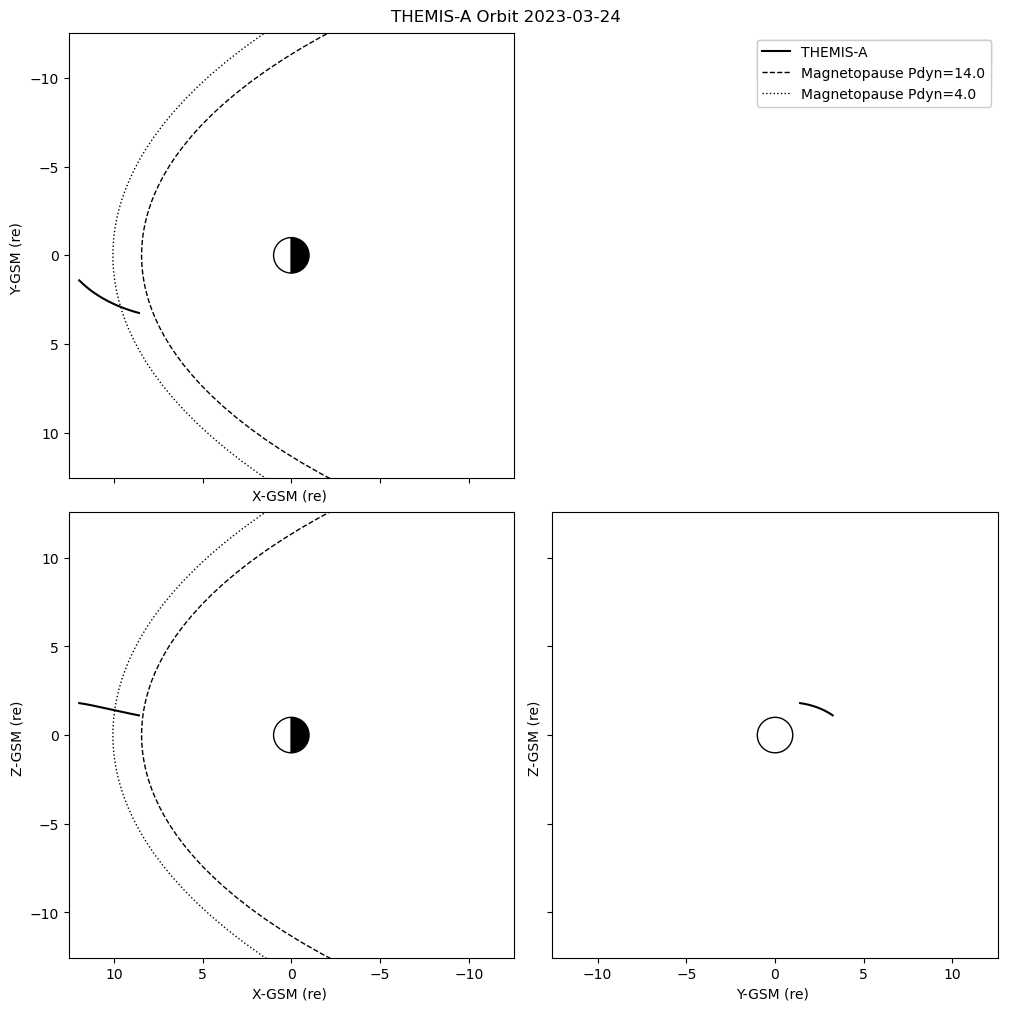

In [32]:
from pyspedas import mpause_t96

# We'll need the position data as arrays rather than tplot variables.  Also, they need to be converted
# from km to Re

tha_pos = get_data('tha_pos_gse')
re = 6378.0
pos_data_re = tha_pos.y / re

# We'll actually model two different boundaries, using different values for the P_dyn parameter of the
# t96 model

xmgnp_lo, ymgnp_lo, zmgnp_lo, id_lo, distan_lo = pyspedas.mpause_t96(
        pd=4.0, xgsm=pos_data_re[:, 0], ygsm=pos_data_re[:, 1], zgsm=pos_data_re[:, 2])

xmgnp_hi, ymgnp_hi, zmgnp_hi, id_hi, distan_hi = pyspedas.mpause_t96(
        pd=14.0, xgsm=pos_data_re[:, 0], ygsm=pos_data_re[:, 1], zgsm=pos_data_re[:, 2])


# Now we'll do another orbit plot with tplotxy3, and add the low pressure and high pressure magnetopause boundaries

fig = tplotxy3('tha_pos_tclip',center_origin=True, reverse_x=True, title="THEMIS-A Orbit 2023-03-24",legend_names=["THEMIS-A"], display=False)
from pyspedas import tplotxy3_add_mpause
tplotxy3_add_mpause(xmgnp_hi, ymgnp_hi,fig=fig,legend_name="Magnetopause Pdyn=14.0",linestyle='dashed', display=False)
tplotxy3_add_mpause(xmgnp_lo, ymgnp_lo,fig=fig,legend_name="Magnetopause Pdyn=4.0",linestyle='dotted', display=True)


Note how close the THEMIS-A orbit is to the magnetopause boundary; in fact, it might be inside or outside depending on the dynamic pressure at that moment!  This is consistent with the multiple magnetopause crossings evident in the THEMIS-A observations.

## Field line tracing and plotting

PySPEDAS now has the capability to do field line tracing, for any of the supported field models, using the routine ttrace2endpoint().

The input position is used as the start point of the trace.  There are three choices available for the trace endpoint:

north ionosphere (the field line is followed northward (that is, parallel with the field vector) until it reaches a defined radius, usually taken as a small increment of a few tens or hundreds of km above Earth)

south ionosphere (as above, but in the direction antiparallel to the field vector), or field line 

apex or magnetic equator (trace parallel or antiparallel to the initial field vector, whichever choice is directed "outward", until the radial component of the field vector changes sign.

The outputs of ttrace2endpoint may include the set of points comprising each field line traced, or the "foot point" (intersection of the trace with the ionosphere, or the apex point in the case of "trace to equator").

Internally, ttrace2endpoint uses an RK45 ODE solver, with an adaptive step size, and some heuristics to refine the trace data as it nears its endpoint.  There are limits to prevent runaway iteration, for example when trying to trace open field lines to the equator or opposite hemisphere.

To demonstrate this, we'll first trace field lines from some THEMIS-A times and positions, to the northern ionosphere, then use tplotxy3 to plot the field lines and the ground tracks of the ionospheric foot points.

For the example we've been using so far, the field line plots are a bit ugly, because many points on the orbit lie on open field lines which get traced to large distances before the solver gives up.  So we'll use a different, better behaved example from early in the THEMIS mission.  We'll also use the T89 model, and let it use the default value for the model parameter Kp.

We'll generate three tplotxy3 figures: one showing the field lines traced from the probe positions to the southern ionosphere; another showing just the foot points from the same trace; and a third plot showing the field lines traced to the equator.



11-Jul-26 01:06:17: File is current: themis_data/tha/l1/state/2007/tha_l1_state_20070323.cdf
11-Jul-26 01:06:17: Setting units for input_var_re
11-Jul-26 01:06:17: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3
11-Jul-26 01:06:20: Computed 100/144 traces so far, current trace time 2007-03-23 16:40:00.000000
11-Jul-26 01:06:21: Max/min trace points: 70 5 at indices 0 108
11-Jul-26 01:06:21: Setting coordinate system for tha_trace_iono_s
11-Jul-26 01:06:21: Setting units for tha_trace_iono_s
11-Jul-26 01:06:21: Setting coordinate system for tha_foot_iono_s
11-Jul-26 01:06:21: Setting units for tha_foot_iono_s


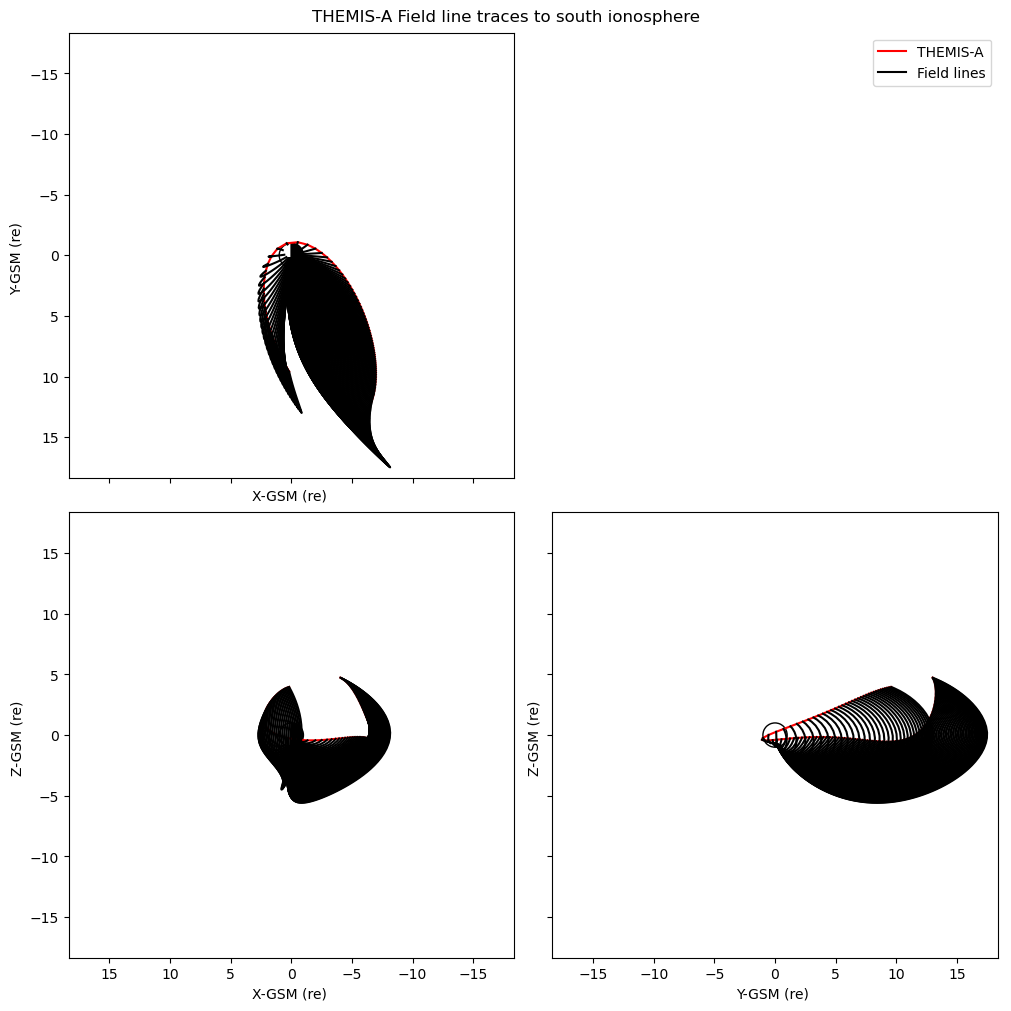

In [14]:
from pyspedas import ttrace2endpoint
import numpy as np

trange=['2007-03-23','2007-03-24']

state(probe='a', trange=trange)

# To make the plots more legible, we'll decimate the probe positions by a factor of 10 (so every 10 minutes, 144 positions total

tstart = time_double('2007-03-23/00:00:00')
posdat = get_data('tha_pos_gsm')
posmd = get_data('tha_pos_gsm',metadata=True)
times = np.zeros(144, dtype=np.float64)
pos = np.zeros((144,3), dtype=np.float64)

for i in range(1440):
    if i % 10 == 0:
       times[int(i/10)] = posdat.times[i]
    pos[int(i/10),:] = posdat.y[i,:]

store_data('tha_pos_red',data={'x':times, 'y':pos}, attr_dict=posmd)

# Now call ttrace2endpoint, using the decimated position variable, and the model parameters we loaded earlier
# The foot_name and trace_name parameters will contain the returned foot points and trace points respectively.

ttrace2endpoint(tvar='tha_pos_red', model_str='t89', endpoint='ionosphere-south', foot_name='tha_foot_iono_s', trace_name='tha_trace_iono_s')

# Show the field line traces

fig = tplotxy3(['tha_pos_red','tha_trace_iono_s'],center_origin=True, reverse_x=True, title="THEMIS-A Field line traces to south ionosphere",legend_names=["THEMIS-A", "Field lines"], colors=['r', 'k'])



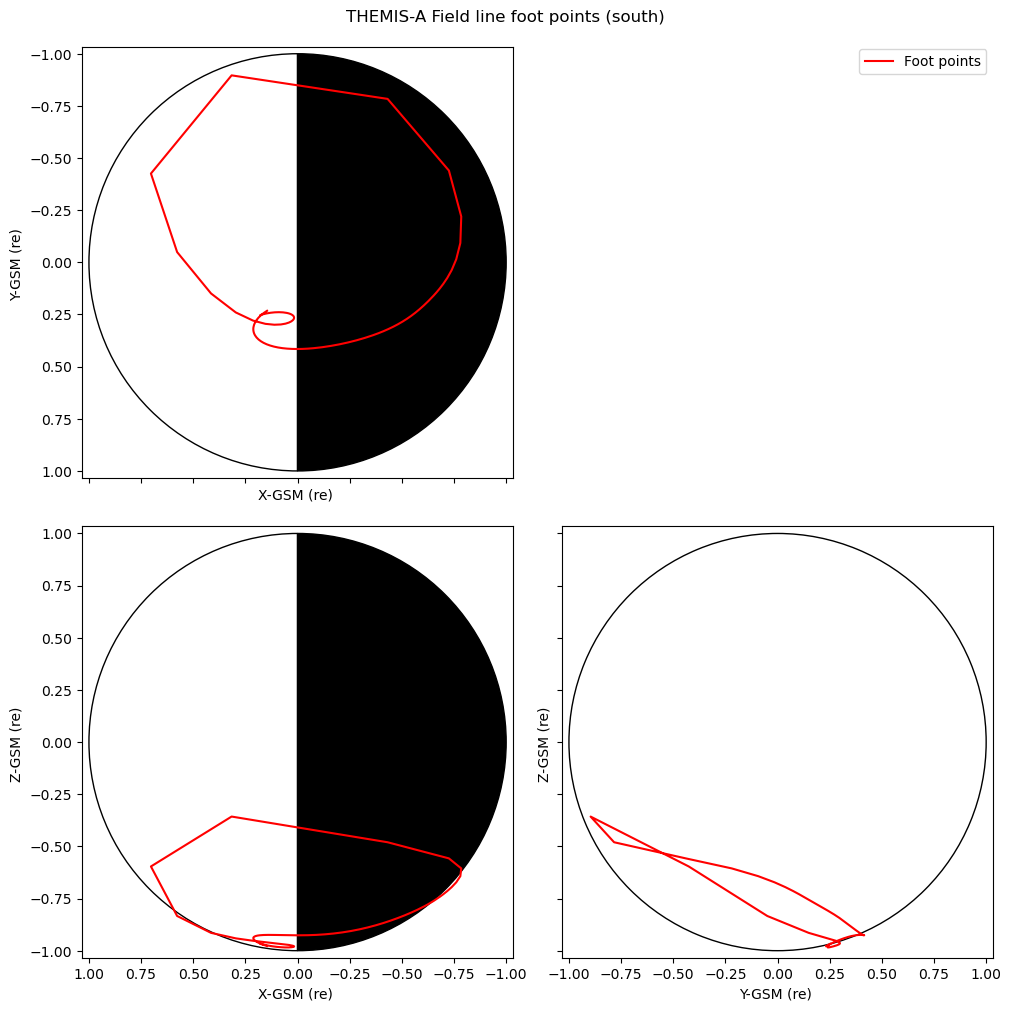

In [15]:
# Now we'll plot the foot points

fig = tplotxy3('tha_foot_iono_s', center_origin=True, reverse_x=True, title="THEMIS-A Field line foot points (south)",legend_names=["Foot points"], colors=['r'])




11-Jul-26 01:06:21: Setting units for input_var_re
11-Jul-26 01:06:21: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3
11-Jul-26 01:06:22: Computed 100/144 traces so far, current trace time 2007-03-23 16:40:00.000000
11-Jul-26 01:06:22: Max/min trace points: 20 4 at indices 0 48
11-Jul-26 01:06:22: Setting coordinate system for tha_trace_equ
11-Jul-26 01:06:22: Setting units for tha_trace_equ
11-Jul-26 01:06:22: Setting coordinate system for tha_foot_equ
11-Jul-26 01:06:22: Setting units for tha_foot_equ


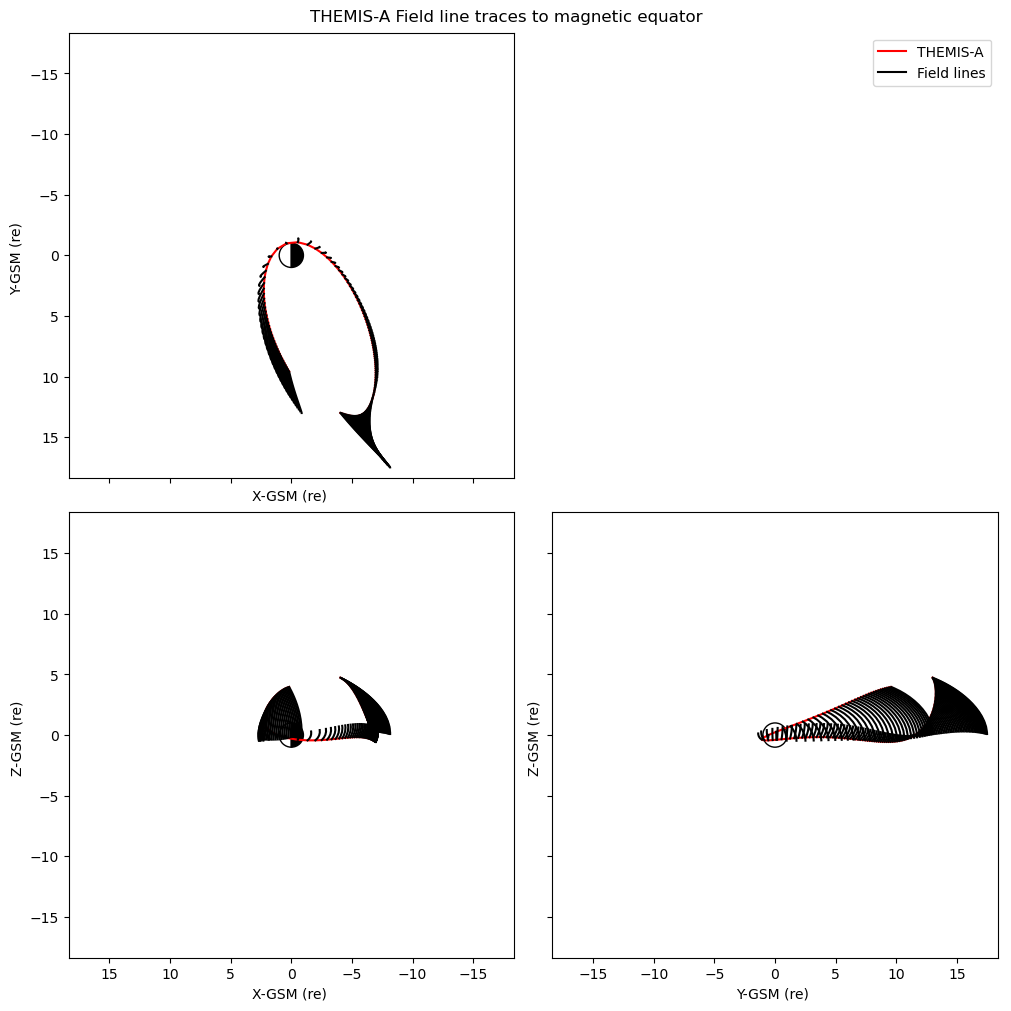

In [16]:
# Now trace to the magnetic equator and plot the field line traces

ttrace2endpoint(tvar='tha_pos_red', model_str='t89', endpoint='equator', foot_name='tha_foot_equ', trace_name='tha_trace_equ')

# Show the field line traces

fig = tplotxy3(['tha_pos_red','tha_trace_equ'],center_origin=True, reverse_x=True, title="THEMIS-A Field line traces to magnetic equator",legend_names=["THEMIS-A", "Field lines"], colors=['r', 'k'], display=False)



We'll do one more field line trace to produce a pretty plot.  This time, instead of using spacecraft data, we'll take evenly spaced points on a circle of radius 5 Re that passes over the magnetic poles.

In [17]:
from pyspedas import set_coords, set_units

def circle_5re():
    start_time = time_double('2007-03-23')
    deg_interval = 5
    npoints = int(360/deg_interval)
    pos=np.zeros((npoints,3), dtype=np.float64)
    times=np.zeros(npoints, dtype=np.float64)
    for i in range(npoints):
        angle=i*deg_interval*np.pi/180.0
        pos[i,0] = 5.0*np.cos(angle)
        pos[i,1] = 0
        pos[i,2] = 5.0*np.sin(angle)
        times[i] = start_time + i
    store_data('circle_5re',data={'x':times,'y':pos})
    set_units('circle_5re', 'Re')
    set_coords('circle_5re', 'GSM')

circle_5re()    
            

11-Jul-26 01:06:23: Setting units for circle_5re
11-Jul-26 01:06:23: Setting coordinate system for circle_5re


In [18]:
ttrace2endpoint('circle_5re', model_str='t89', endpoint='ionosphere-south', trace_name='circle_5re_trace_iono_s')


11-Jul-26 01:06:23: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3
11-Jul-26 01:06:23: ttrace2endpoint: Found max_s trace point at index 13 2007-03-23 00:00:13.000000
11-Jul-26 01:06:23: ttrace2endpoint: Found max_s trace point at index 14 2007-03-23 00:00:14.000000
11-Jul-26 01:06:23: ttrace2endpoint: Found max_s trace point at index 15 2007-03-23 00:00:15.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 16 2007-03-23 00:00:16.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 17 2007-03-23 00:00:17.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 18 2007-03-23 00:00:18.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 19 2007-03-23 00:00:19.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 20 2007-03-23 00:00:20.000000
11-Jul-26 01:06:24: ttrace2endpoint: Found max_s trace point at index 21 2007-03-23 00:00:21.000000
1

11-Jul-26 01:06:26: /var/folders/_4/hbrtgs_j1qlgl2f3fwjw2_kc0000gn/T/ipykernel_8698/3837032737.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



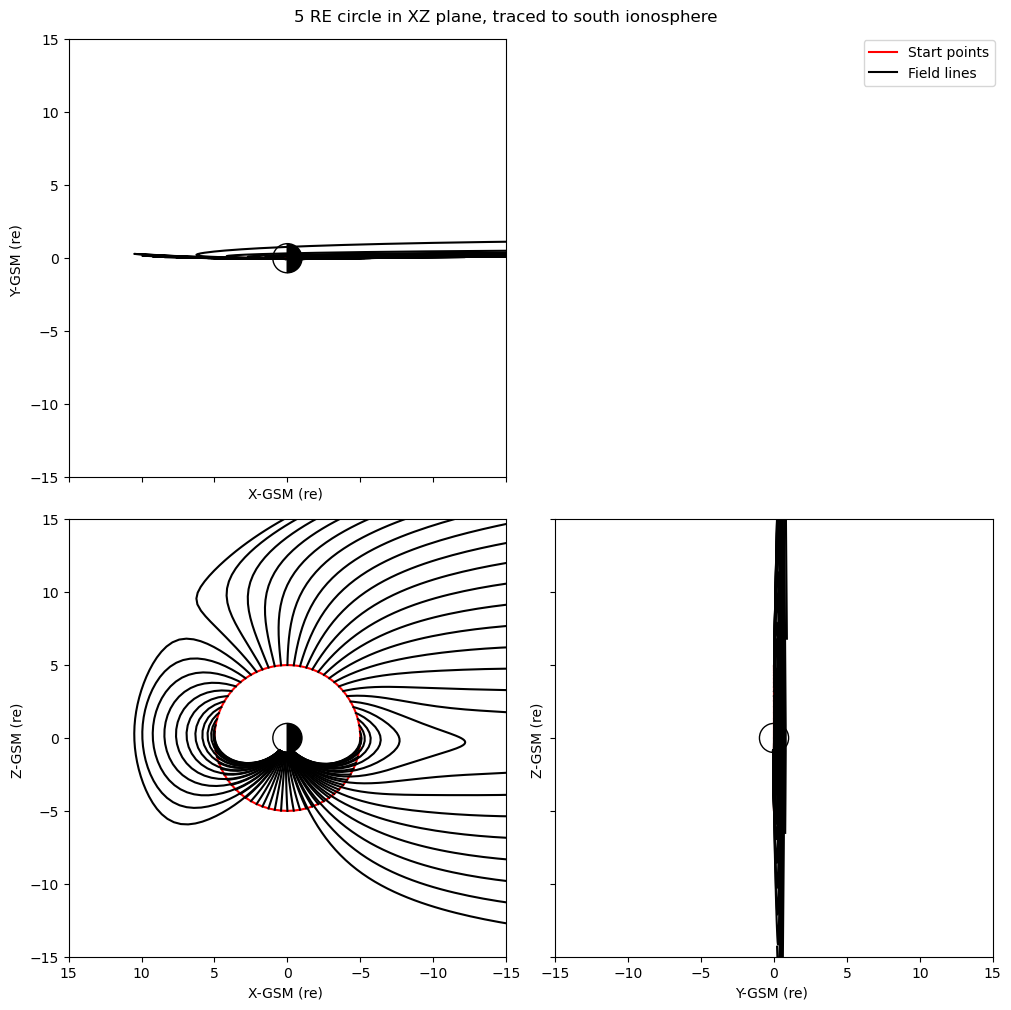

In [19]:
fig = tplotxy3(['circle_5re', 'circle_5re_trace_iono_s'], center_origin=True, reverse_x=True, colors=['r','k'], 
               title='5 RE circle in XZ plane, traced to south ionosphere', 
               legend_names=['Start points', 'Field lines'], 
               display=False)

# We'll adjust the x and y ranges of the individual planes to make a better plot

xy = fig.xy_plane
xz = fig.xz_plane
yz = fig.yz_plane

xy.set_xlim(15, -15)
xy.set_ylim(-15, 15)

xz.set_xlim(15, -15)
xz.set_ylim(-15, 15)

yz.set_xlim(-15, 15)
yz.set_ylim(-15, 15)

fig.show()